# Checkpoint 5

In [11]:
dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
full_train_data = dataset.shuffle()

In [14]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size #...
        self.optimizer = optim.Adam(self.model.parameters(),lr=learning_rate,weight_decay=l2) #...
        self.epoch = epoch #...
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True): #early stopping! :)
        self.model.train()
        
        # init data loader
        #print("Initialize training data...")
        #train_data_loader = train_data.collate(self.batch_size)
        #train_data_loader = DataLoader(train_data,batch_size=self.batch_size,shuffle=True) #...
        #val_data_loader = DataLoader(val_data,batch_size=self.batch_size,shuffle=True)

        #train_loss_list, val_loss_list = trainer.train(train_data_loader, val_data_loader, draw_curve=False)

        #train_data_loader = train_data.collate(self.batch_size).cache()

        # definition of loss function: MSE is a good choice! 
        loss_func = torch.nn.MSELoss() #...
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data:
                
                # compute energies #...
                # (self) assuming train data batch has inputs and true_energies
                #inputs, true_energies=train_data_batch
                species = train_data_batch['species'].to(device)
                coordinates = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()

                _, pred_energies = self.model((species, coordinates))
                
                #pred_energies=self.model(inputs)
                
                # compute loss
                batch_loss = loss_func(pred_energies,true_energies) #...
                
                # do a step #...
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = 1 #... this assumes all batches are equally impt - double check
                train_epoch_loss += batch_loss.item()*batch_importance #...
            
            # use the self.evaluate to get loss on the validation set 
            #val_epoch_loss, _ = self.evaluate(val_data,draw_plot=False) #...
            
            # append the losses
            #...

            train_loss_list.append(train_epoch_loss / len(train_data))
            if val_data is not None:
                val_epoch_loss, _ = self.evaluate(val_data, draw_plot=False)
                val_loss_list.append(val_epoch_loss)

                if early_stop:
                    if val_epoch_loss < lowest_val_loss:
                        lowest_val_loss = val_epoch_loss
                        weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            #ax.plot(range(self.epoch),train_loss_list, label='Train')
            #ax.plot(range(self.epoch),val_loss_list, label='Validation')
            
            ax.plot(range(len(train_loss_list)), train_loss_list, label='Train')
            
            if val_data is not None and len(val_loss_list) > 0:
                ax.plot(range(len(val_loss_list)), val_loss_list, label='Validation')

            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        #if early_stop:
            #self.model.load_state_dict(weights)
        if early_stop and val_data is not None and 'weights' in locals():
            self.model.load_state_dict(weights)

        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        self.model.eval()
        
        # init data loader
        #data_loader = DataLoader(data,batch_size=self.batch_size,shuffle=False) #...
        #data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = torch.nn.MSELoss() #...
        total_loss = 0.0
        
        #if draw_plot:
        true_energies_all = []
        pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data:
            #for batch_data in data_loader:
                
                # compute energies #...
                #inputs,true_energies=batch_data
                #pred_energies=self.model(inputs)
                species = batch_data['species'].to(device)
                coordinates = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()

                _, pred_energies = self.model((species, coordinates))
                
                # compute loss
                batch_loss = loss_func(pred_energies,true_energies) #...

                batch_importance = 1 #...
                total_loss += batch_loss.item()*batch_importance #...
                
                #if draw_plot:
                true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())
                    
        true_energies_all = np.concatenate(true_energies_all)
        pred_energies_all = np.concatenate(pred_energies_all)
        hartree2kcalmol = 627.5094738898777
        mae = np.mean(np.abs(true_energies_all - pred_energies_all))*hartree2kcalmol

        if draw_plot:
            #true_energies_all = np.concatenate(true_energies_all)
            #pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            #hartree2kcalmol = 627.5094738898777 #...
            #mae = np.mean(np.abs(true_energies_all - pred_energies_all))*hartree2kcalmol #... in kcal/mol 
            fig, ax = plt.subplots(1,1,figsize=(5,4),constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss, mae

Sequential - Number of parameters: 526340


100%|██████████| 10/10 [04:26<00:00, 26.61s/it]


final run  MAE: 1.311 kcal/mol
final run loss: 0.001


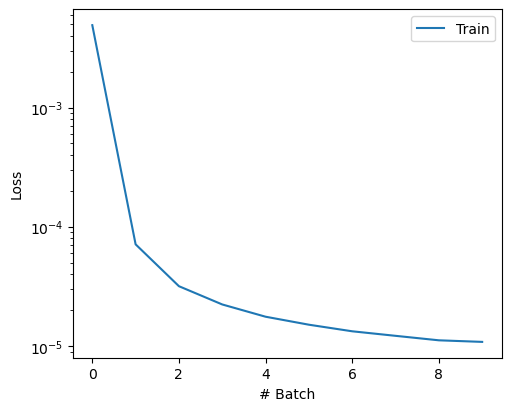

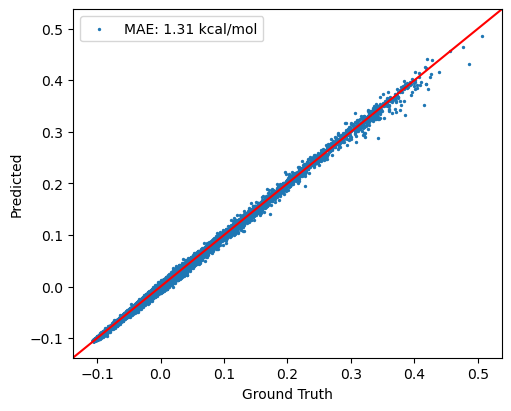

In [15]:
model = atomic_model(aev_computer, hidden_sizes=[256,128], dropout=0.0, device=device)
train_loader = full_train_data.collate(batch_size=8192)

trainer = ANITrainer(model,batch_size=8192,learning_rate=0.001,epoch=10,l2=0.0)
train_loss_list, _ = trainer.train(train_loader,None,draw_curve=True)

test_loader=test_data.collate(batch_size=1024)
final_test_loss, final_test_mae=trainer.evaluate(test_loader,draw_plot=True)

print(f"final run  MAE: {final_test_mae:.3f} kcal/mol")
print(f"final run loss: {final_test_loss:.3f}")